In [4]:
# === IMPORTS BÁSICOS E CONFIGURAÇÃO INICIAL ===

from pathlib import Path                     # Manipulação de caminhos de arquivos/pastas
import pandas as pd                           # Tabelas e manipulação de dados
import numpy as np                            # Utilidades numéricas
import fastf1                                 # API de dados de F1
from fastf1 import plotting                   # (opcional) utilidades extras do pacote

# === DEFINIÇÃO DE DIRETÓRIOS DO PROJETO ===
PROJ = Path.cwd().resolve().parent            # Diretório atual (raiz do projeto, se você abriu o notebook de lá)
DATA_DIR = PROJ / "data"                      # Pasta principal de dados
DATA_DIR.mkdir(exist_ok=True)                 # Garante que a pasta data exista
(DATA_DIR / "interim").mkdir(parents=True, exist_ok=True)   # Garante subpasta para dados intermediários

# === ATIVA CACHÊ LOCAL DO FASTF1 ===
CACHE_DIR = PROJ / "fastf1_cache"             # Pasta para cache do FastF1
CACHE_DIR.mkdir(exist_ok=True)                # Cria a pasta se não existir
fastf1.Cache.enable_cache(str(CACHE_DIR))     # Ativa o cache para acelerar chamadas futuras

# (opcional) estilos de plot do fastf1
plotting.setup_mpl(misc_mpl_mods=False)



In [5]:
# === FUNÇÕES AUXILIARES REUTILIZÁVEIS ===

def to_seconds(td):
    """Converte um pandas.Timedelta (ou NaT) para float em segundos."""
    return np.nan if pd.isna(td) else td.total_seconds()

def ensure_tyre_age(df: pd.DataFrame) -> pd.DataFrame:
    """Garante a coluna TyreLife; se ausente ou toda NaN, reconstrói por (Driver, Stint)."""
    df = df.copy()
    if "TyreLife" not in df.columns or df["TyreLife"].isna().all():
        # Ordena por piloto, stint e número da volta
        df = df.sort_values(["Driver", "Stint", "LapNumber"])
        # Conta cumulativamente as voltas dentro de cada stint (1,2,3,...)
        df["TyreLife"] = df.groupby(["Driver", "Stint"]).cumcount() + 1
    return df

def extract_event_laps(year: int, event_name: str) -> pd.DataFrame:
    """
    Extrai TODAS as voltas da CORRIDA (Race, 'R') para um (ano, evento) específico.
    Mantém in/out laps marcadas; converte tempos; agrega clima via merge_asof.
    Retorna um DataFrame pronto para concatenação posterior.
    """
    # Carrega a sessão de corrida do ano/evento usando FastF1
    session = fastf1.get_session(year, event_name, "R")
    session.load()  # Baixa dados (1ª vez) e usa cache nas próximas

    # Obtém todas as voltas como DataFrame
    laps = session.laps.reset_index(drop=True).copy()

    # Garante que colunas de pit existam mesmo se ausentes em alguma temporada
    for c in ["PitInTime", "PitOutTime"]:
        if c not in laps.columns:
            laps[c] = pd.NaT

    # Cria flags de in-lap/out-lap e uma flag agregada
    laps["IsPitInLap"]   = laps["PitInTime"].notna().astype(int)
    laps["IsPitOutLap"]  = laps["PitOutTime"].notna().astype(int)
    laps["IsInOrOutLap"] = (laps["IsPitInLap"] | laps["IsPitOutLap"]).astype(int)

    # Converte tempos de volta e setores para segundos mantendo o timedelta original
    for c in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
        if c in laps.columns:
            laps[c + "Sec"] = laps[c].apply(to_seconds)

    # Garante idade do pneu (TyreLife)
    laps = ensure_tyre_age(laps)

    # Adiciona metadados úteis
    laps["Year"] = year
    laps["EventName"] = event_name
    laps["Session"] = "Race"

    # Junta dados de clima da sessão (merge pelo tempo)
    weather = session.weather_data.copy()
    if weather is not None and not weather.empty and "Time" in weather.columns:
        # Alinha tipos para merge_asof (ambos como Timedelta)
        tmp = laps.copy()
        tmp["Time"] = pd.to_timedelta(tmp["Time"])
        weather["Time"] = pd.to_timedelta(weather["Time"])
        # Faz merge_asof pegando o valor de clima mais próximo no passado
        laps = pd.merge_asof(
            tmp.sort_values("Time"),
            weather[["Time","AirTemp","TrackTemp","Humidity","Pressure","WindSpeed","WindDirection"]].sort_values("Time"),
            on="Time", direction="backward"
        )

    # Ordena por piloto e volta para deixar o dataset “limpo”
    laps = laps.sort_values(["Driver", "LapNumber"]).reset_index(drop=True)
    return laps


In [6]:
# === ENTRADA DO USUÁRIO: INTERVALO DE ANOS E LISTAGEM DE CIRCUITOS ===

# Solicita ao usuário o ano inicial
year_start = int(input("Digite o ano INICIAL (ex.: 2018): ").strip())
# Solicita ao usuário o ano final
year_end   = int(input("Digite o ano FINAL   (ex.: 2024): ").strip())

# Garante que o intervalo esteja em ordem crescente
if year_end < year_start:
    year_start, year_end = year_end, year_start

# Cria uma lista de anos do intervalo (inclusive)
YEARS = list(range(year_start, year_end + 1))
print(f"Intervalo de anos selecionado: {YEARS}")

# Para descobrir quais eventos existem nesses anos, consultamos o calendário anual do FastF1
all_events = []                                 # Lista para acumular DataFrames de calendários
for y in YEARS:
    cal = fastf1.get_event_schedule(y, include_testing=False)  # Calendário oficial sem testes
    cal["Year"] = y                                           # Marca o ano no calendário
    all_events.append(cal[["Year","EventName","OfficialEventName","EventDate","Location"]])

# Concatena todos os calendários em um único DataFrame
events_df = pd.concat(all_events, ignore_index=True)

# Levanta a lista de eventos únicos que aparecem em pelo menos um dos anos
unique_events = sorted(events_df["EventName"].dropna().unique().tolist())

# Exibe uma lista enumerada para o usuário escolher o circuito
print("\n=== Circuitos com corridas válidas no intervalo ===")
for i, name in enumerate(unique_events, start=1):
    print(f"{i:2d}. {name}")

# Solicita ao usuário que escolha um índice da lista
idx = int(input("\nDigite o número do circuito desejado: ").strip())
# Valida o índice informado
if not (1 <= idx <= len(unique_events)):
    raise ValueError("Índice inválido. Rode novamente e escolha um número listado.")

# Obtém o nome do circuito selecionado
SELECTED_EVENT = unique_events[idx - 1]
print(f"\nVocê selecionou: {SELECTED_EVENT}")


Intervalo de anos selecionado: [2022, 2023, 2024]


C:\Users\pedro\AppData\Local\Temp\ipykernel_12092\2112252472.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal["Year"] = y                                           # Marca o ano no calendário
C:\Users\pedro\AppData\Local\Temp\ipykernel_12092\2112252472.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal["Year"] = y                                           # Marca o ano no calendário



=== Circuitos com corridas válidas no intervalo ===
 1. Abu Dhabi Grand Prix
 2. Australian Grand Prix
 3. Austrian Grand Prix
 4. Azerbaijan Grand Prix
 5. Bahrain Grand Prix
 6. Belgian Grand Prix
 7. British Grand Prix
 8. Canadian Grand Prix
 9. Chinese Grand Prix
10. Dutch Grand Prix
11. Emilia Romagna Grand Prix
12. French Grand Prix
13. Hungarian Grand Prix
14. Italian Grand Prix
15. Japanese Grand Prix
16. Las Vegas Grand Prix
17. Mexico City Grand Prix
18. Miami Grand Prix
19. Monaco Grand Prix
20. Qatar Grand Prix
21. Saudi Arabian Grand Prix
22. Singapore Grand Prix
23. Spanish Grand Prix
24. São Paulo Grand Prix
25. United States Grand Prix


C:\Users\pedro\AppData\Local\Temp\ipykernel_12092\2112252472.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cal["Year"] = y                                           # Marca o ano no calendário


ValueError: invalid literal for int() with base 10: 'Jeddah'

In [ ]:
# === EXTRAÇÃO EM LOTE: PARA CADA ANO DO INTERVALO, COLETA AS VOLTAS DO EVENTO ESCOLHIDO ===

all_laps_list = []                               # Lista para acumular os DataFrames de cada ano
errors = []                                       # Lista para registrar anos que por algum motivo falharam

for y in YEARS:
    try:
        # Tenta extrair as voltas do evento selecionado naquele ano
        df_year = extract_event_laps(y, SELECTED_EVENT)
        # Acrescenta o DataFrame obtido na lista
        all_laps_list.append(df_year)
        # Log simples de sucesso
        print(f"[OK] {SELECTED_EVENT} {y}: {len(df_year)} voltas extraídas.")
    except Exception as e:
        # Em caso de erro (evento pode não ter corrida em algum ano), registra e segue
        print(f"[ERRO] {SELECTED_EVENT} {y}: {e}")
        errors.append((y, str(e)))

# Concatena tudo em um único DataFrame (se houver pelo menos um sucesso)
if all_laps_list:
    laps_all_years = pd.concat(all_laps_list, ignore_index=True)
    print(f"\nTotal de voltas combinadas: {len(laps_all_years)}")
else:
    raise RuntimeError("Nenhuma corrida foi extraída. Verifique o intervalo e o circuito selecionado.")


core           INFO 	Loading data for São Paulo Grand Prix - Race [v3.6.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No 

[OK] São Paulo Grand Prix 2022: 1259 voltas extraídas.


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Failed to align laps for driver

[OK] São Paulo Grand Prix 2023: 1109 voltas extraídas.


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!

[OK] São Paulo Grand Prix 2024: 1135 voltas extraídas.

Total de voltas combinadas: 3503


In [ ]:
# === SALVAMENTO DO DATASET COMBINADO ===

# Monta nomes de arquivos de saída com base nas escolhas do usuário
safe_event = SELECTED_EVENT.lower().replace(" ", "_")
out_csv = DATA_DIR / "interim" / f"{safe_event}_{year_start}-{year_end}_all_laps.csv"
out_parq = DATA_DIR / "interim" / f"{safe_event}_{year_start}-{year_end}_all_laps.parquet"

# Salva em CSV e Parquet
laps_all_years.to_csv(out_csv, index=False)
laps_all_years.to_parquet(out_parq, index=False)

# Mostra caminhos e uma amostra das colunas
print(f"CSV salvo em:     {out_csv}")
print(f"Parquet salvo em: {out_parq}")
display(laps_all_years.head(10))


CSV salvo em:     C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\data\interim\são_paulo_grand_prix_2022-2024_all_laps.csv
Parquet salvo em: C:\Users\pedro\iCloudDrive\Desktop\Eng. Elétrica UNESP Bauru 2020\TG\TG2\f1-tyre-strategy-simulator\data\interim\são_paulo_grand_prix_2022-2024_all_laps.parquet


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Sector3TimeSec,Year,EventName,Session,AirTemp,TrackTemp,Humidity,Pressure,WindSpeed,WindDirection
0,0 days 01:03:39.272000,ALB,23,0 days 00:01:52.761000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:53.750000,...,31.389,2022,São Paulo Grand Prix,Race,23.5,49.5,75.0,922.2,1.5,160
1,0 days 01:05:31.662000,ALB,23,0 days 00:01:52.390000,2.0,1.0,NaT,NaT,0 days 00:00:26.235000,0 days 00:01:01.874000,...,24.281,2022,São Paulo Grand Prix,Race,23.7,49.5,74.0,922.2,1.0,154
2,0 days 01:07:29.630000,ALB,23,0 days 00:01:57.968000,3.0,1.0,NaT,NaT,0 days 00:00:34.160000,0 days 00:01:01.167000,...,22.641,2022,São Paulo Grand Prix,Race,23.3,49.0,74.0,922.2,1.6,168
3,0 days 01:09:33.684000,ALB,23,0 days 00:02:04.054000,4.0,1.0,NaT,0 days 01:09:30.812000,0 days 00:00:31.598000,0 days 00:01:07.246000,...,25.210,2022,São Paulo Grand Prix,Race,23.3,48.3,74.0,922.2,2.0,203
4,0 days 01:11:28.710000,ALB,23,0 days 00:01:55.026000,5.0,2.0,0 days 01:09:55.214000,NaT,0 days 00:00:39.240000,0 days 00:00:48.322000,...,27.464,2022,São Paulo Grand Prix,Race,23.3,48.2,74.0,922.2,1.5,156
5,0 days 01:13:14.860000,ALB,23,0 days 00:01:46.150000,6.0,2.0,NaT,NaT,0 days 00:00:29.970000,0 days 00:00:48.106000,...,28.074,2022,São Paulo Grand Prix,Race,23.2,48.9,74.0,922.2,1.2,0
6,0 days 01:14:36.281000,ALB,23,0 days 00:01:21.421000,7.0,2.0,NaT,NaT,0 days 00:00:21.051000,0 days 00:00:42.907000,...,17.463,2022,São Paulo Grand Prix,Race,23.2,48.3,75.0,922.0,1.1,211
7,0 days 01:15:55.526000,ALB,23,0 days 00:01:19.245000,8.0,2.0,NaT,NaT,0 days 00:00:20.072000,0 days 00:00:41.463000,...,17.710,2022,São Paulo Grand Prix,Race,23.4,47.6,75.0,922.0,1.2,155
8,0 days 01:17:13.528000,ALB,23,0 days 00:01:18.002000,9.0,2.0,NaT,NaT,0 days 00:00:19.761000,0 days 00:00:40.993000,...,17.248,2022,São Paulo Grand Prix,Race,23.6,49.1,74.0,922.0,1.0,127
9,0 days 01:18:31.416000,ALB,23,0 days 00:01:17.888000,10.0,2.0,NaT,NaT,0 days 00:00:19.743000,0 days 00:00:40.728000,...,17.417,2022,São Paulo Grand Prix,Race,23.7,49.1,74.0,922.2,1.2,129


count    mean     std     min     25%     50%     75%      max
Year Compound                                                                
2022 HARD       13.0  86.382  16.012  77.341  77.920  78.145  78.625  117.968
     MEDIUM    547.0  81.515  12.178  74.283  76.289  77.102  78.178  122.448
     SOFT      607.0  84.240  15.057  73.785  76.050  76.828  78.822  125.656
2023 MEDIUM    333.0  76.182   0.645  74.682  75.721  76.100  76.559   78.311
     SOFT      653.0  76.695   5.302  72.486  75.119  76.313  76.968  132.670

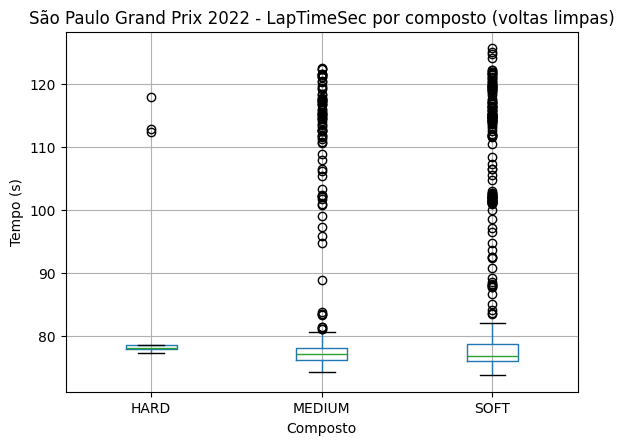

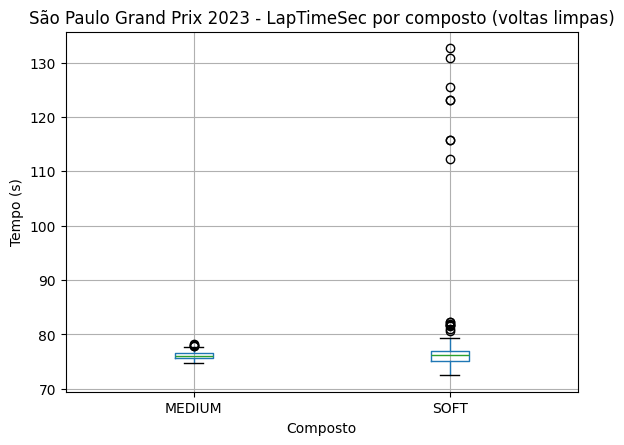

In [ ]:
# === EDA RÁPIDA: VOLTAS LIMPAS E COMPOSTOS SECOS ===

# Cria um subconjunto removendo in/out laps para análise de ritmo
clean = laps_all_years[(laps_all_years["IsInOrOutLap"] == 0)].copy()

# Se quiser focar em pneus secos apenas:
if "Compound" in clean.columns:
    clean = clean[clean["Compound"].isin(["SOFT","MEDIUM","HARD"])]

# Estatísticas simples por ano e composto (se disponível)
if "Compound" in clean.columns:
    stats = (clean.groupby(["Year","Compound"])["LapTimeSec"]
                  .describe()[["count","mean","std","min","25%","50%","75%","max"]]
                  .round(3))
    display(stats.head(12))

# Boxplot simples (pode requerer muitos dados, ajuste se achar pesado)
import matplotlib.pyplot as plt
if "Compound" in clean.columns:
    for y in YEARS:
        subset = clean[clean["Year"] == y]
        if not subset.empty:
            subset.boxplot(column="LapTimeSec", by="Compound")
            plt.title(f"{SELECTED_EVENT} {y} - LapTimeSec por composto (voltas limpas)")
            plt.suptitle("")
            plt.xlabel("Composto")
            plt.ylabel("Tempo (s)")
            plt.show()
